In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
import numpy as np
# Suppress warnings to keep the output clean for the demonstration
warnings.filterwarnings("ignore")

In [2]:
def adfuller_test(series, title=''):
    """Performs and prints the results of the Augmented Dickey-Fuller test.
        H0 : Series is non stationary
        HA : Series is Stationary
    """
    print(f'\n--- ADF Test Results for {title} ---')
    result = adfuller(series, autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        print(f'{label}: {value:.4f}')

    if result[1] <= 0.05:
        print("Result: Series is stationary (p-value <= 0.05)")
    else:
        print("Result: Series is non-stationary (p-value > 0.05)")

In [3]:
# --- 1. Load and Prepare the Data ---
print("--- Step 1: Loading and Preprocessing the Data ---")

# The `statsmodels` dataset module can sometimes cause import errors.
# A more robust way to load the Air Passengers dataset is directly from a CSV file.
data = pd.read_csv("airline-passengers.csv", parse_dates=['Month'])
data.rename(columns={'Month': 'month', 'Passengers': 'passengers'}, inplace=True)
#data['month'] = pd.to_datetime(data['month']).dt.to_period('M')
data.set_index('month', inplace=True)

# Use the original passenger data without any transformations.
y = data['passengers']

--- Step 1: Loading and Preprocessing the Data ---


In [5]:
data

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461



Plotting the original data to visualize trend and seasonality...


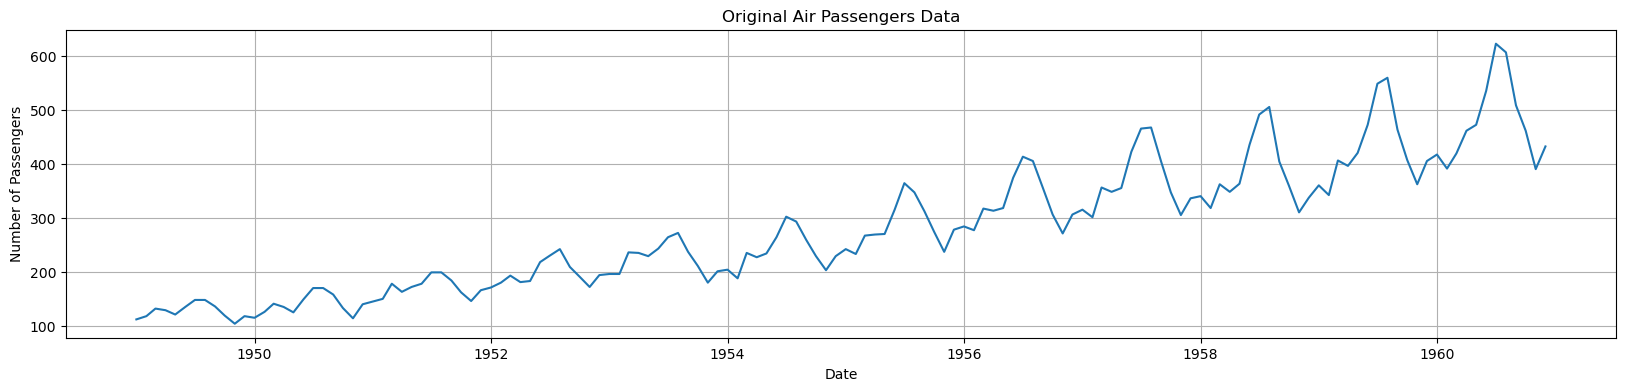

In [6]:
# Visualize the data to observe its characteristics
print("\nPlotting the original data to visualize trend and seasonality...")
plt.figure(figsize=(20, 4))
plt.plot(y)
plt.title('Original Air Passengers Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

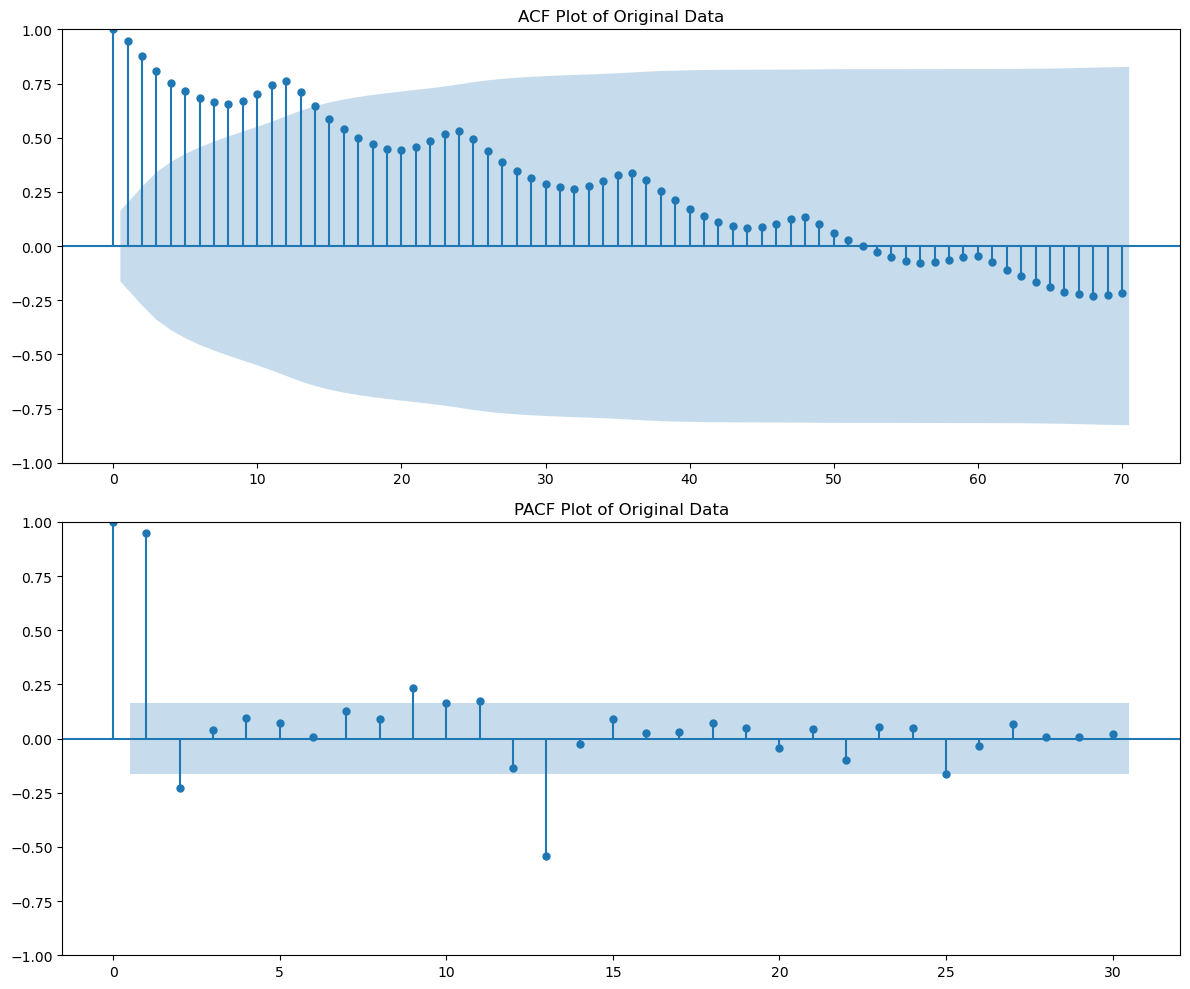

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
# Plot the Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(y, lags=70, ax=axes[0])
axes[0].set_title('ACF Plot of Original Data')

# Plot the Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(y, lags=30, ax=axes[1])
axes[1].set_title('PACF Plot of Original Data')

plt.tight_layout()
plt.show()

In [12]:
m = 12 

In [10]:
adfuller_test(y, title='Original Series')


--- ADF Test Results for Original Series ---
ADF Statistic: 0.8154
p-value: 0.9919
#Lags Used: 13.0000
Number of Observations Used: 130.0000
Result: Series is non-stationary (p-value > 0.05)


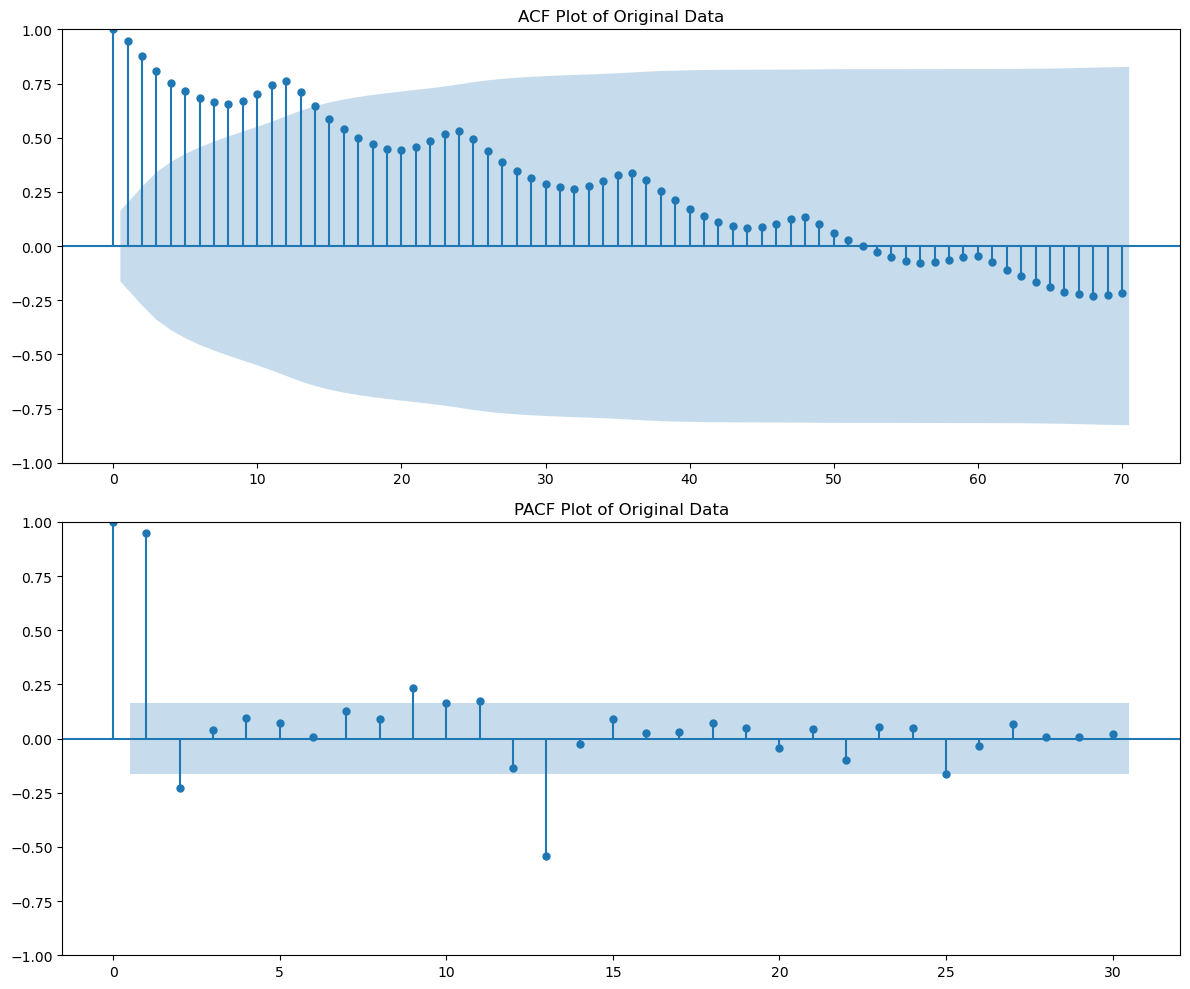

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
# Plot the Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(y, lags=70, ax=axes[0])
axes[0].set_title('ACF Plot of Original Data')

# Plot the Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(y, lags=30, ax=axes[1])
axes[1].set_title('PACF Plot of Original Data')

plt.tight_layout()
plt.show()

In [13]:
y_diff_seasonal = y.diff(m).dropna()

In [14]:
y_diff_seasonal

month
1950-01-01     3.0
1950-02-01     8.0
1950-03-01     9.0
1950-04-01     6.0
1950-05-01     4.0
              ... 
1960-08-01    47.0
1960-09-01    45.0
1960-10-01    54.0
1960-11-01    28.0
1960-12-01    27.0
Name: passengers, Length: 132, dtype: float64


Plotting the seasonally differenced data...


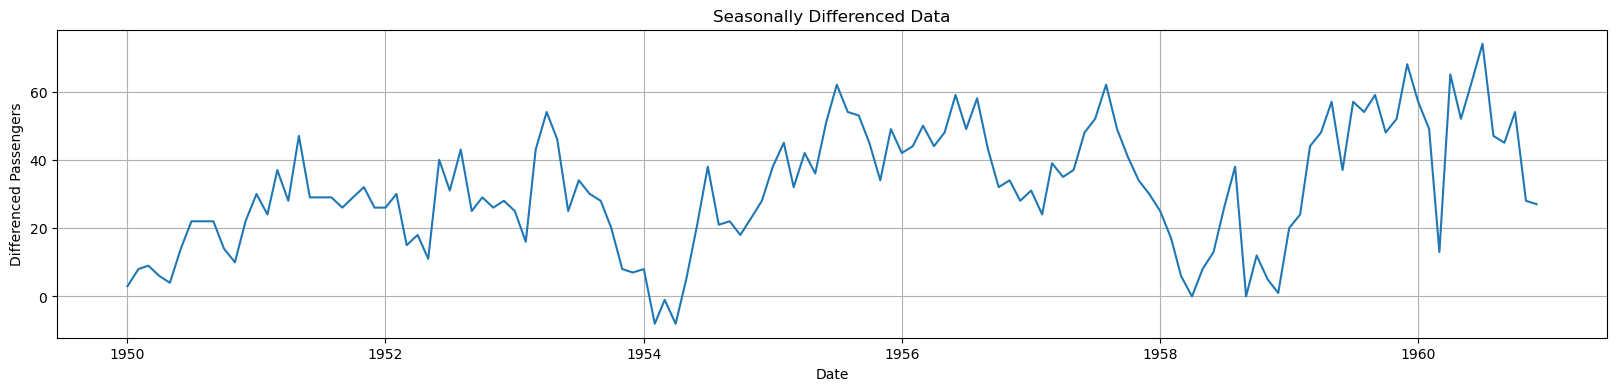

In [15]:
# Apply seasonal differencing (D=1) with a lag of 12.
print("\nPlotting the seasonally differenced data...")
plt.figure(figsize=(20, 4))
plt.plot(y_diff_seasonal)
plt.title('Seasonally Differenced Data')
plt.xlabel('Date')
plt.ylabel('Differenced Passengers')
plt.grid(True)
plt.show()

In [16]:
# Test the seasonally differenced series for stationarity
adfuller_test(y_diff_seasonal, title='Seasonally Differenced Series')


--- ADF Test Results for Seasonally Differenced Series ---
ADF Statistic: -3.3830
p-value: 0.0116
#Lags Used: 1.0000
Number of Observations Used: 130.0000
Result: Series is stationary (p-value <= 0.05)


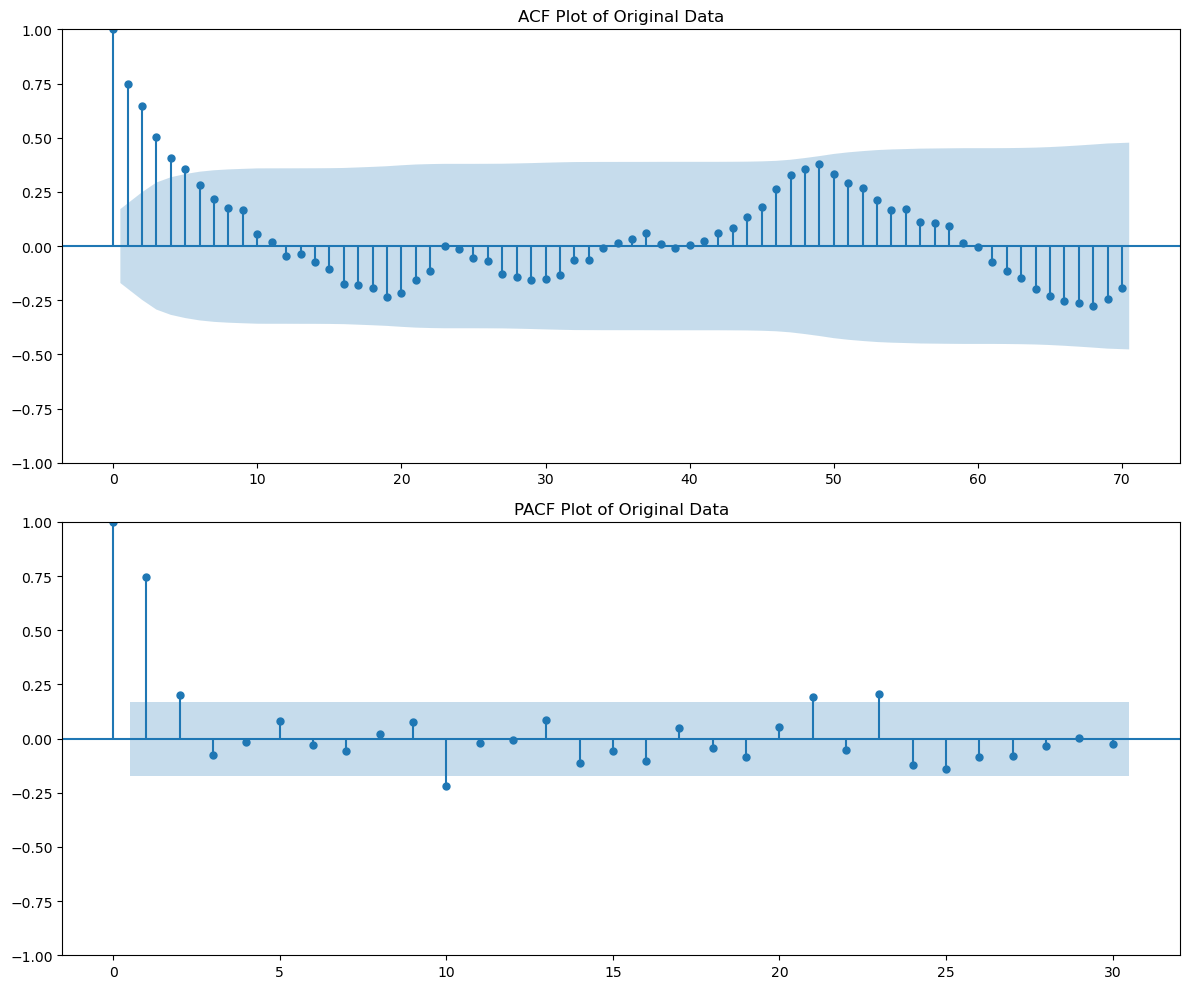

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
# Plot the Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(y_diff_seasonal, lags=70, ax=axes[0])
axes[0].set_title('ACF Plot of Original Data')

# Plot the Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(y_diff_seasonal, lags=30, ax=axes[1])
axes[1].set_title('PACF Plot of Original Data')

plt.tight_layout()
plt.show()

In [19]:
# Apply non-seasonal differencing (d=1) to the seasonally differenced data.
y_diff_total = y_diff_seasonal.diff(1).dropna()


Plotting the fully differenced data...


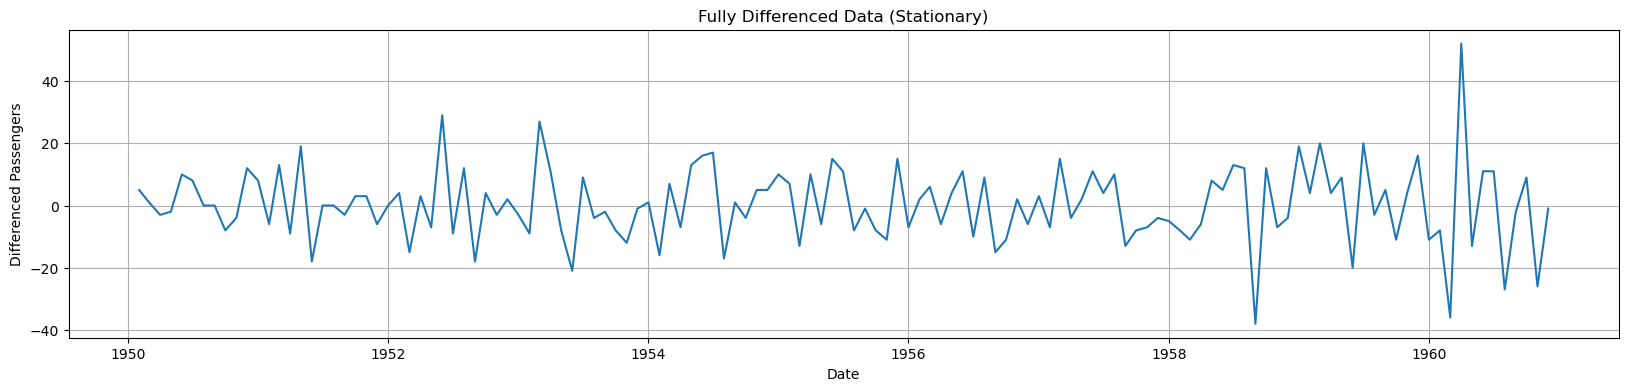

In [20]:
print("\nPlotting the fully differenced data...")
plt.figure(figsize=(20, 4))
plt.plot(y_diff_total)
plt.title('Fully Differenced Data (Stationary)')
plt.xlabel('Date')
plt.ylabel('Differenced Passengers')
plt.grid(True)
plt.show()

In [21]:
# Test the fully differenced series for stationarity
adfuller_test(y_diff_total, title='Fully Differenced Series')


--- ADF Test Results for Fully Differenced Series ---
ADF Statistic: -15.5956
p-value: 0.0000
#Lags Used: 0.0000
Number of Observations Used: 130.0000
Result: Series is stationary (p-value <= 0.05)


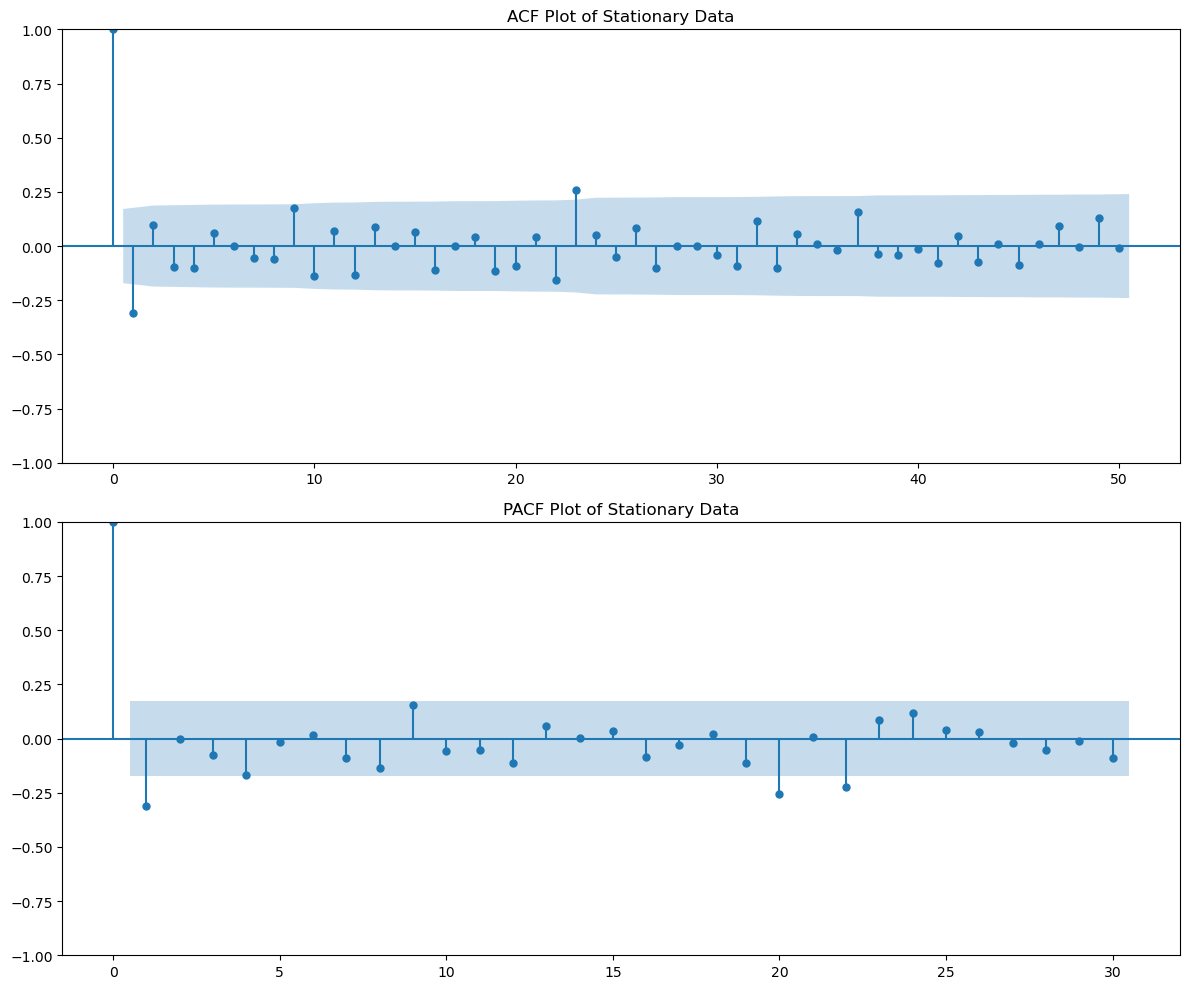

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
# Plot the Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(y_diff_total, lags=50, ax=axes[0])
axes[0].set_title('ACF Plot of Stationary Data')

# Plot the Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(y_diff_total, lags=30, ax=axes[1])
axes[1].set_title('PACF Plot of Stationary Data')

plt.tight_layout()
plt.show()

In [ ]:
d = 1
D = 1
m = 12 

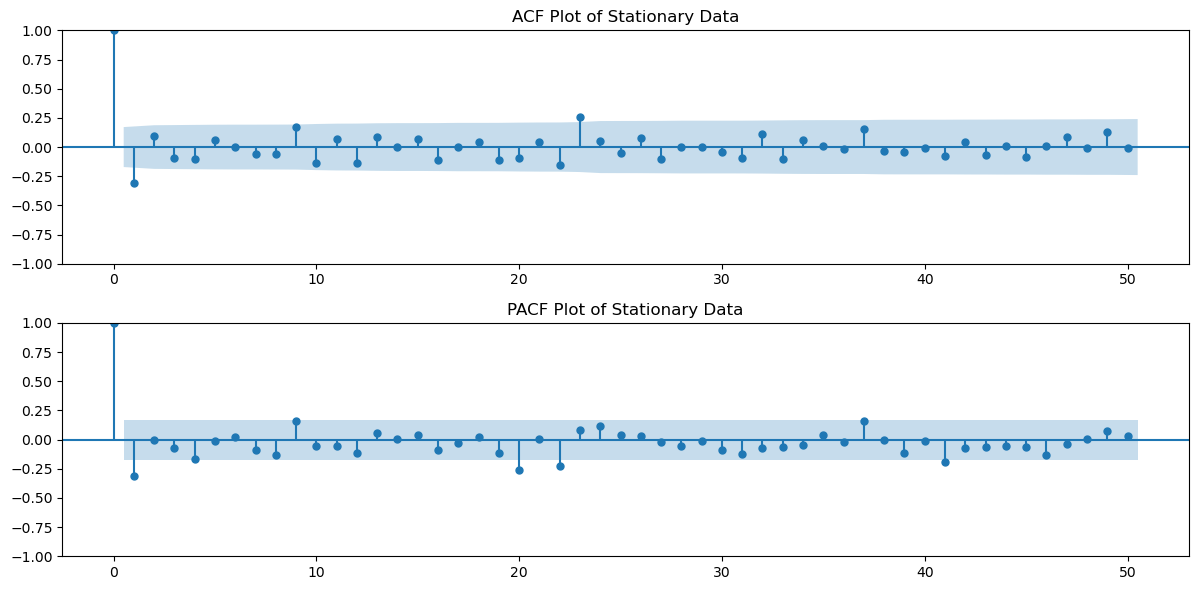

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
# Plot the Autocorrelation Function (ACF)
sm.graphics.tsa.plot_acf(y_diff_total, lags=50, ax=axes[0])
axes[0].set_title('ACF Plot of Stationary Data')

# Plot the Partial Autocorrelation Function (PACF)
sm.graphics.tsa.plot_pacf(y_diff_total, lags=50, ax=axes[1])
axes[1].set_title('PACF Plot of Stationary Data')

plt.tight_layout()
plt.show()

In [ ]:
p = 1
P = 0

In [ ]:
q = 1
Q = 0

In [ ]:
AIC : -2 log L + 2(p+q+k+1) 

In [27]:
-2 * -501.276 + 2 * 3

1008.552

In [25]:
# --- 4. Fitting the SARIMA Model ---
print("\n--- Step 4: Fitting the SARIMA(1, 1, 1)x(0,1,0, 12) Model ---")
# Define and fit the SARIMA model using the identified parameters.
sarima_model = sm.tsa.SARIMAX(y,
                             order=(1, 1, 1),
                             seasonal_order=(0, 1, 0, 12),
                             enforce_stationarity=False,
                             enforce_invertibility=False)

results = sarima_model.fit()

# Print the model summary to review the coefficients, p-values, and AIC/BIC.
print(results.summary())


--- Step 4: Fitting the SARIMA(1, 1, 1)x(0,1,0, 12) Model ---
                                      SARIMAX Results                                      
Dep. Variable:                          passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 12)   Log Likelihood                -501.276
Date:                             Sat, 04 Oct 2025   AIC                           1008.553
Time:                                     11:40:10   BIC                           1017.132
Sample:                                 01-01-1949   HQIC                          1012.039
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3056      0.357     -0.856

In [72]:
# --- 4. Fitting the SARIMA Model ---
print("\n--- Step 4: Fitting the SARIMA(1, 1, 1)x(1,1,1, 12) Model ---")
# Define and fit the SARIMA model using the identified parameters.
sarima_model = sm.tsa.SARIMAX(y,
                             order=(5, 1, 5),
                             seasonal_order=(2, 1, 2, 12),
                             enforce_stationarity=False,
                             enforce_invertibility=False)

results = sarima_model.fit()

# Print the model summary to review the coefficients, p-values, and AIC/BIC.
print(results.summary())


--- Step 4: Fitting the SARIMA(1, 1, 1)x(1,1,1, 12) Model ---
                                        SARIMAX Results                                        
Dep. Variable:                              passengers   No. Observations:                  144
Model:             SARIMAX(5, 1, 5)x(2, 1, [1, 2], 12)   Log Likelihood                -389.229
Date:                                 Sat, 04 Oct 2025   AIC                            808.459
Time:                                         12:13:11   BIC                            847.686
Sample:                                     01-01-1949   HQIC                           824.339
                                          - 12-01-1960                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1      


--- Step 5: Performing Diagnostic Checks on Residuals ---


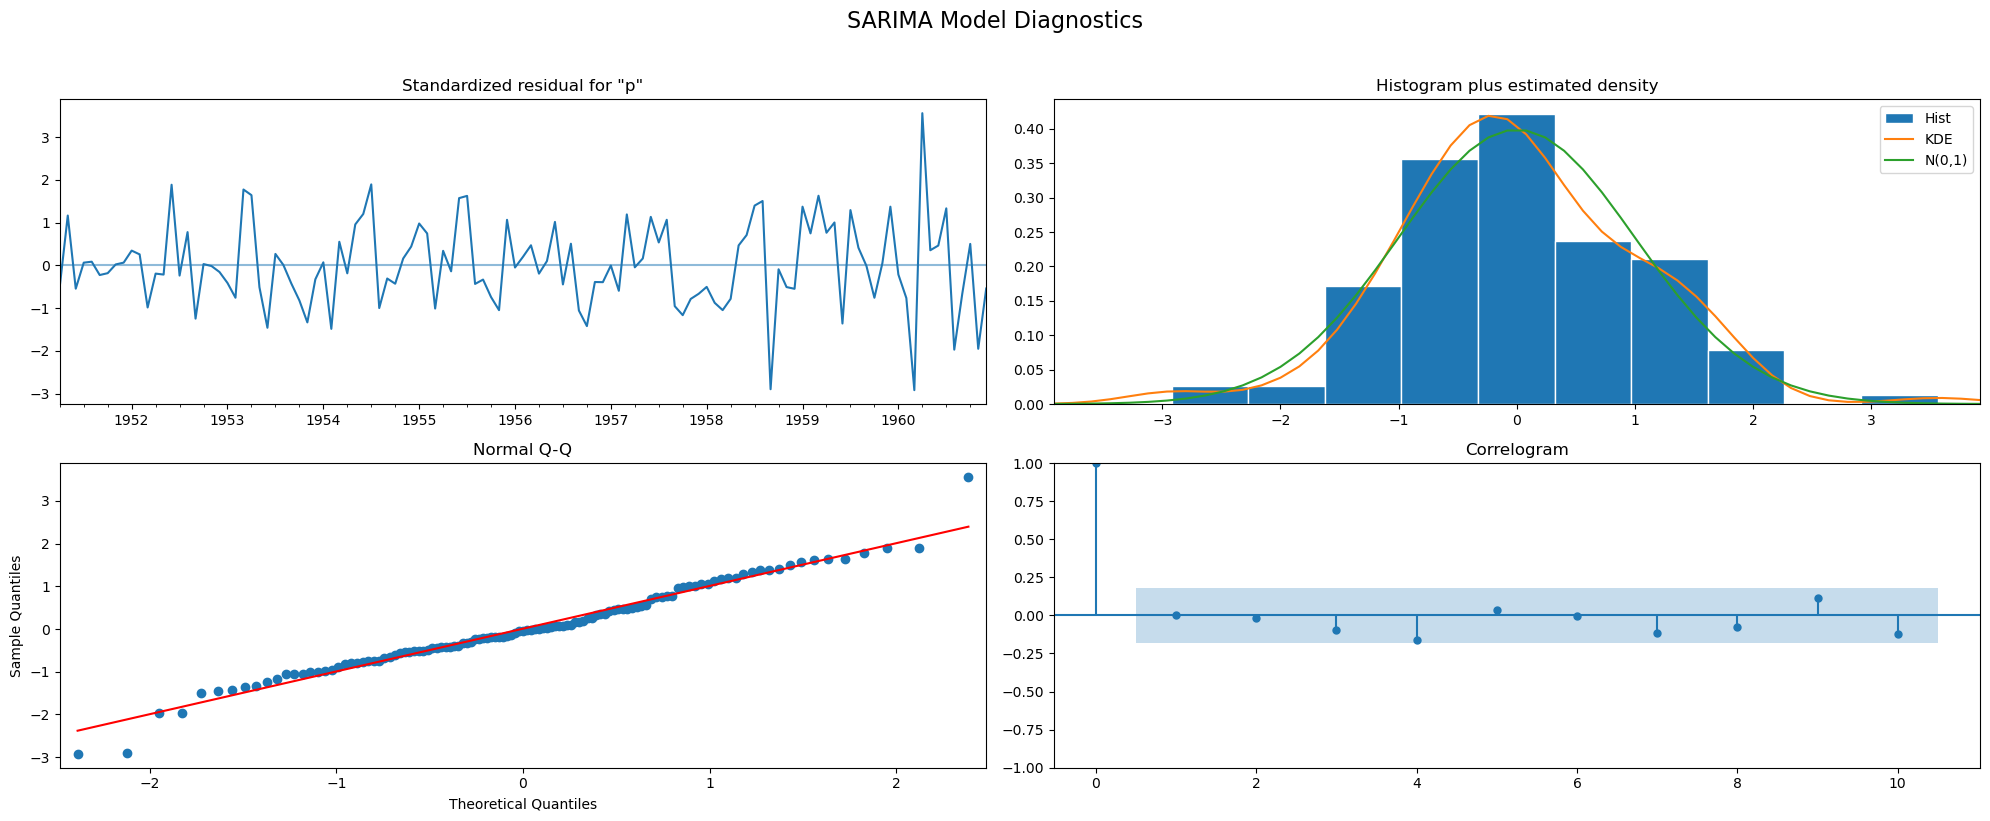

In [64]:
# --- 5. Diagnostic Checks ---
print("\n--- Step 5: Performing Diagnostic Checks on Residuals ---")
# Analyze the residuals to ensure the model is a good fit.
results.plot_diagnostics(figsize=(20, 8))
plt.suptitle('SARIMA Model Diagnostics', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [65]:
# --- 6. Forecasting with SARIMA ---
print("\n--- Step 6: Forecasting Future Values ---")
# We will now forecast 36 months (3 years) into the future.
n_forecast = 60
forecast = results.get_forecast(steps=n_forecast)


--- Step 6: Forecasting Future Values ---


In [66]:
# Get the forecasted values and the confidence intervals.
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [51]:
forecast_mean

1961-01-01    444.352151
1961-02-01    418.244539
1961-03-01    446.277423
1961-04-01    488.267375
1961-05-01    499.270445
1961-06-01    562.269507
1961-07-01    649.269794
1961-08-01    633.269706
1961-09-01    535.269733
1961-10-01    488.269725
1961-11-01    417.269727
1961-12-01    459.269727
Freq: MS, Name: predicted_mean, dtype: float64

In [52]:
from sklearn.metrics import mean_squared_error

In [53]:
results.fittedvalues

month
1949-01-01      0.000000
1949-02-01    100.591575
1949-03-01    118.745887
1949-04-01    131.585662
1949-05-01    129.130107
                 ...    
1960-08-01    629.564622
1960-09-01    518.371798
1960-10-01    452.664450
1960-11-01    413.206931
1960-12-01    441.064377
Length: 144, dtype: float64

In [67]:
np.std(y-results.fittedvalues,ddof=1)

15.765530312939783

In [55]:
mean_squared_error(y,results.fittedvalues,squared=False)

16.286191664075584

In [41]:
16.286191664075584*1.96

31.920935661588146

In [42]:
444.352151 + 31.57238332815117

475.92453432815114

In [56]:
forecast_mean.head()

1961-01-01    444.352151
1961-02-01    418.244539
1961-03-01    446.277423
1961-04-01    488.267375
1961-05-01    499.270445
Freq: MS, Name: predicted_mean, dtype: float64

In [45]:
467.452808 - 444.352151

23.100657000000012

In [46]:
444.352151 - 421.251493

23.10065800000001

In [48]:
y-results.fittedvalues

month
1949-01-01    112.000000
1949-02-01     17.408425
1949-03-01     13.254113
1949-04-01     -2.585662
1949-05-01     -8.130107
                 ...    
1960-08-01    -23.564622
1960-09-01    -10.371798
1960-10-01      8.335550
1960-11-01    -23.206931
1960-12-01     -9.064377
Length: 144, dtype: float64

In [57]:
forecast_ci

,lower passengers,upper passengers
1961-01-01,421.251493,467.452808
1961-02-01,390.187875,446.301204
1961-03-01,412.880200,479.674647
1961-04-01,450.587986,525.946764
1961-05-01,457.661711,540.879180
1961-06-01,517.096157,607.442857
1961-07-01,600.786296,697.753291
1961-08-01,581.690042,684.849370
1961-09-01,480.768937,589.770529
1961-10-01,430.996759,545.542691


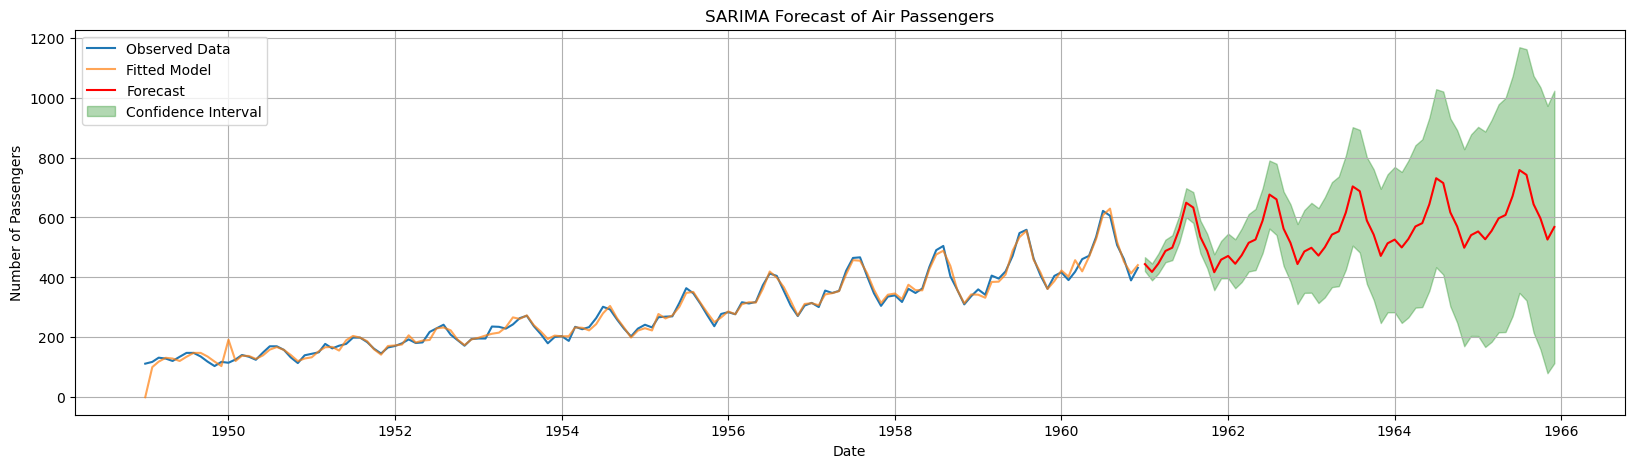

In [61]:
# Plot the original data, the fitted values, and the forecast
plt.figure(figsize=(20, 5))
plt.plot(data.index, data['passengers'], label='Observed Data')
plt.plot(pd.to_datetime(results.fittedvalues.index.astype(str)),
         results.fittedvalues, label='Fitted Model', alpha=0.7)
# Plot the forecasted values and the confidence interval
plt.plot(pd.to_datetime(forecast_mean.index.astype(str)),
         forecast_mean, label='Forecast', color='red')
plt.fill_between(pd.to_datetime(forecast_ci.index.astype(str)),
                 forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='green', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Forecast of Air Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

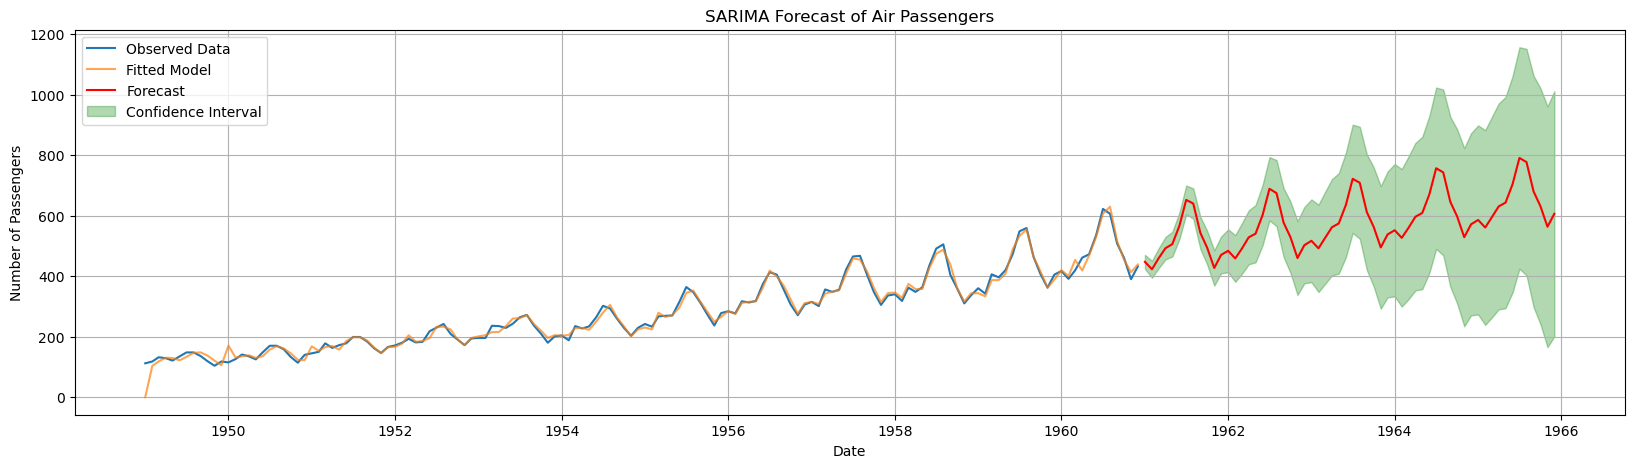

In [68]:
# Plot the original data, the fitted values, and the forecast
plt.figure(figsize=(20, 5))
plt.plot(data.index, data['passengers'], label='Observed Data')
plt.plot(pd.to_datetime(results.fittedvalues.index.astype(str)),
         results.fittedvalues, label='Fitted Model', alpha=0.7)
# Plot the forecasted values and the confidence interval
plt.plot(pd.to_datetime(forecast_mean.index.astype(str)),
         forecast_mean, label='Forecast', color='red')
plt.fill_between(pd.to_datetime(forecast_ci.index.astype(str)),
                 forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='green', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Forecast of Air Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [73]:
import pmdarima as pm

In [96]:
import itertools
p = q = range(1,4)
d = range(1,2)
pdq = list(itertools.product(p,d,q))

In [97]:
pdq

[(1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [103]:
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(range(1,3), range(1,2), range(1,3)))]
seasonal_pdq

[(1, 1, 1, 12), (1, 1, 2, 12), (2, 1, 1, 12), (2, 1, 2, 12)]

In [104]:
len(seasonal_pdq)

4

In [105]:
len(pdq)

9

In [106]:
4 * 9

36

In [107]:
best_aic = np.inf
best_order = None
best_seasonal = None
best_model = None

for order in pdq:
    for seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.SARIMAX(y, order=order, seasonal_order=seasonal, enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = order
                best_seasonal = seasonal
                best_model = res
            print(pdq,seasonal_pdq)
        except Exception as e:
            continue

print("Best SARIMAX by AIC:", best_order, best_seasonal, "AIC:", best_aic)

Best SARIMAX by AIC: (2, 1, 3) (1, 1, 2, 12) AIC: 810.6844198973383


In [108]:
# --- 4. Fitting the SARIMA Model ---
print("\n--- Step 4: Fitting the SARIMA(2, 1, 3) x (1, 1, 2, 12) Model ---")
# Define and fit the SARIMA model using the identified parameters.
sarima_model = sm.tsa.SARIMAX(y,
                             order=(2,1,3),
                             seasonal_order=(1,1, 2, 12),
                             enforce_stationarity=False,
                             enforce_invertibility=False)

results = sarima_model.fit()

# Print the model summary to review the coefficients, p-values, and AIC/BIC.
print(results.summary())


--- Step 4: Fitting the SARIMA(2, 1, 3) x (1, 1, 2, 12) Model ---
                                        SARIMAX Results                                        
Dep. Variable:                              passengers   No. Observations:                  144
Model:             SARIMAX(2, 1, 3)x(1, 1, [1, 2], 12)   Log Likelihood                -396.342
Date:                                 Sat, 04 Oct 2025   AIC                            810.684
Time:                                         12:40:08   BIC                            834.397
Sample:                                     01-01-1949   HQIC                           820.289
                                          - 12-01-1960                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1  


--- Step 5: Performing Diagnostic Checks on Residuals ---


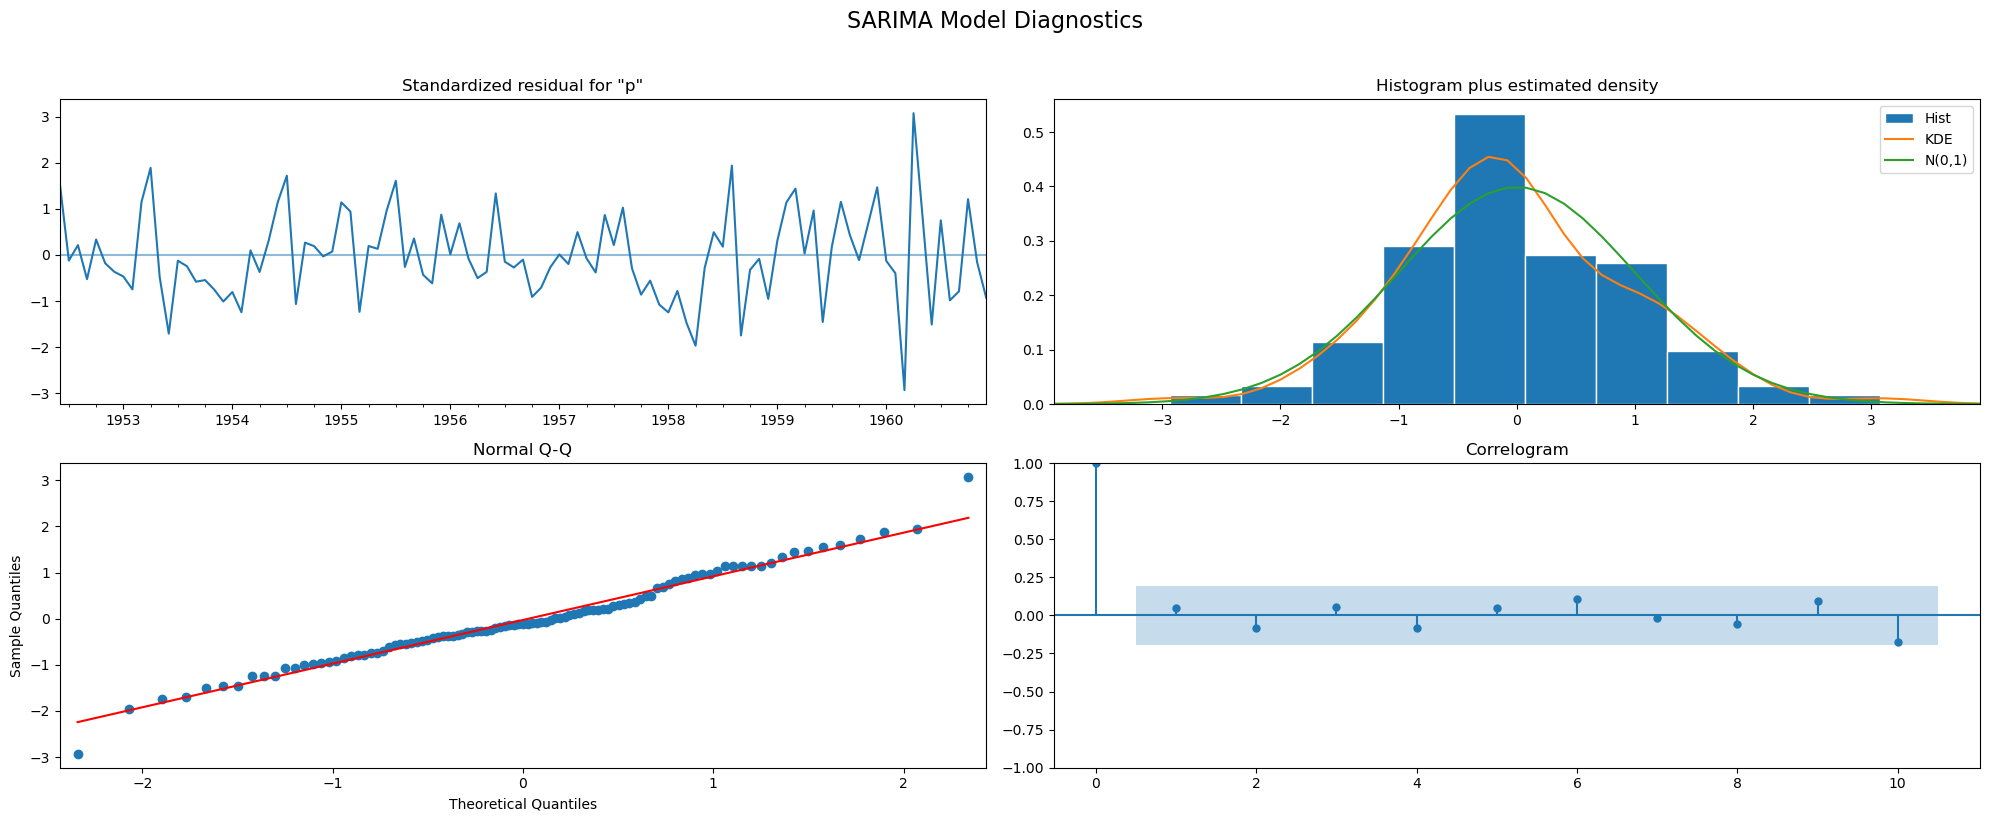

In [109]:
# --- 5. Diagnostic Checks ---
print("\n--- Step 5: Performing Diagnostic Checks on Residuals ---")
# Analyze the residuals to ensure the model is a good fit.
results.plot_diagnostics(figsize=(20, 8))
plt.suptitle('SARIMA Model Diagnostics', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [110]:
# --- 6. Forecasting with SARIMA ---
print("\n--- Step 6: Forecasting Future Values ---")
# We will now forecast 36 months (3 years) into the future.
n_forecast = 60
forecast = results.get_forecast(steps=n_forecast)


--- Step 6: Forecasting Future Values ---


In [111]:
# Get the forecasted values and the confidence intervals.
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

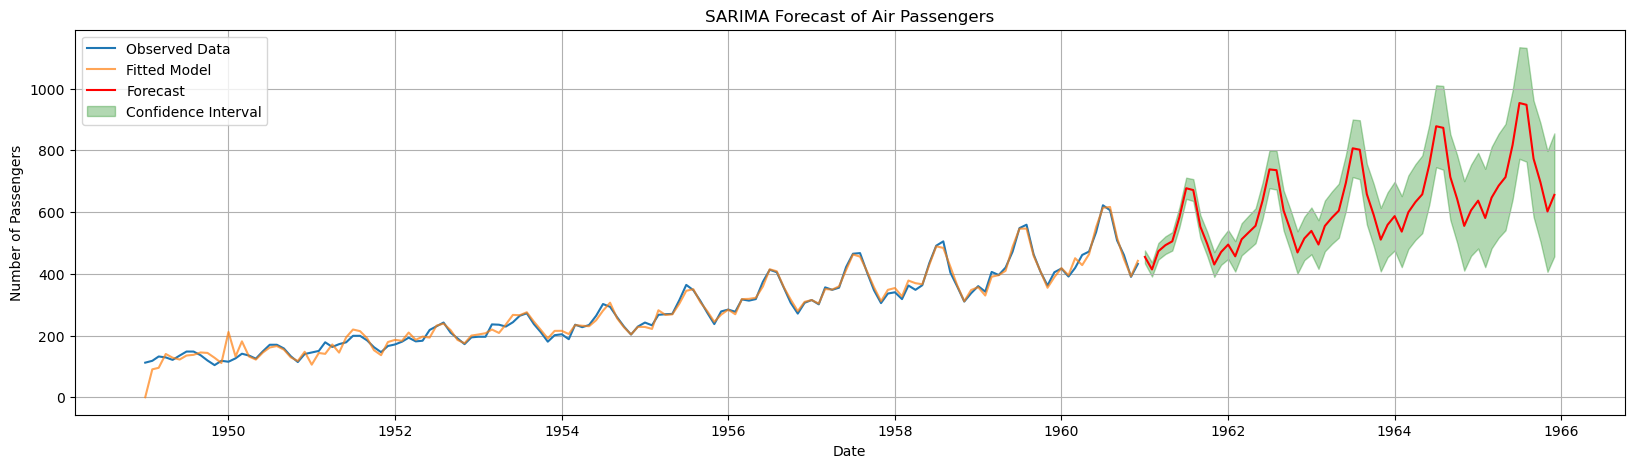

In [112]:
# Plot the original data, the fitted values, and the forecast
plt.figure(figsize=(20, 5))
plt.plot(data.index, data['passengers'], label='Observed Data')
plt.plot(pd.to_datetime(results.fittedvalues.index.astype(str)),
         results.fittedvalues, label='Fitted Model', alpha=0.7)
# Plot the forecasted values and the confidence interval
plt.plot(pd.to_datetime(forecast_mean.index.astype(str)),
         forecast_mean, label='Forecast', color='red')
plt.fill_between(pd.to_datetime(forecast_ci.index.astype(str)),
                 forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 color='green', alpha=0.3, label='Confidence Interval')

plt.title('SARIMA Forecast of Air Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()